In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [ ]:
df = pd.read_csv("MMDental\medical_records.csv")

TEXT_COLS = [
    "Main appeal",
    "Subsequent",
    "Present medical history",
    "Past medical history",
    "Oral Check",
    "Treatment plan",
    "Handle",
    "Doctor advices"
]

df[TEXT_COLS] = df[TEXT_COLS].fillna("").astype(str)
df["Diagnosis"] = df["Diagnosis"].fillna("").astype(str)

df["Report"] = df[TEXT_COLS].agg(" ".join, axis=1)

final_df = (
    df.groupby("Filename")
      .agg({
          "Sex": "first",
          "Age": "first",
          "Report": " ".join,
          "Diagnosis": " ".join
      })
      .reset_index()
)


In [ ]:
DISEASE_CLASSES = [
    "Apical periodontitis",
    "Periodontitis",
    "Gingivitis",
    "Crooked teeth",
    "Damaged or missing teeth",
    "Impacted tooth",
    "Caries",
    "Pulpitis"
]

In [ ]:
DISEASE_KEYWORDS = {
    "Apical periodontitis": ["apical periodontitis"],
    "Periodontitis": ["periodontitis"],
    "Gingivitis": ["gingivitis"],
    "Crooked teeth": ["malocclusion", "crooked"],
    "Damaged or missing teeth": ["missing", "damaged"],
    "Impacted tooth": ["impacted"],
    "Caries": ["caries"],
    "Pulpitis": ["pulpitis"]
}

def extract_single_disease(text):
    text = text.lower()
    for disease, keys in DISEASE_KEYWORDS.items():
        for k in keys:
            if k in text:
                return disease
    return "Unknown"

In [ ]:
final_df["target_disease"] = final_df["Diagnosis"].apply(extract_single_disease)
final_df = final_df[final_df["target_disease"] != "Unknown"].reset_index(drop=True)

In [ ]:
disease_to_id = {d: i for i, d in enumerate(DISEASE_CLASSES)}
id_to_disease = {i: d for d, i in disease_to_id.items()}

final_df["label"] = final_df["target_disease"].map(disease_to_id)

In [ ]:
final_df.to_csv("mmdental_multiclass_new.csv", index=False)

In [ ]:
final_df["target_disease"].unique()

array(['Impacted tooth', 'Apical periodontitis', 'Periodontitis',
       'Gingivitis', 'Pulpitis', 'Crooked teeth',
       'Damaged or missing teeth', 'Caries'], dtype=object)

In [ ]:
import torch
import os

sample_file = os.listdir("MMDental_preprocessed")[0]
x = torch.load(os.path.join("MMDental_preprocessed", sample_file))

print("Sample file:", sample_file)
print("Shape:", x.shape)
print("Dtype:", x.dtype)

Sample file: 1.pt
Shape: torch.Size([1, 224, 224, 224])
Dtype: torch.float32


C:\Users\T2510590\AppData\Local\Temp\ipykernel_6828\2882672419.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(os.path.join("MMDental_preprocessed", sampl

In [ ]:
import os

pt_dir = "MMDental_preprocessed"

# All available image IDs
available_ids = set(
    int(f.replace(".pt", ""))
    for f in os.listdir(pt_dir)
    if f.endswith(".pt")
)

print("Available images:", len(available_ids))

# Keep only rows that have images
filtered_df = final_df[
    final_df["Filename"].astype(int).isin(available_ids)
].reset_index(drop=True)

print("Rows before filtering:", len(final_df))
print("Rows after filtering:", len(filtered_df))


Available images: 403
Rows before filtering: 526
Rows after filtering: 322


In [ ]:

filtered_df.to_csv("mmdental_multiclass_new.csv", index=False)

In [ ]:
# import os

# pt_dir = "MMDental_augmented"

# # All available image IDs
# available_ids = set(
#     int(f.replace(".pt", ""))
#     for f in os.listdir(pt_dir)
#     if f.endswith(".pt")
# )

# print("Available images:", len(available_ids))

# # Keep only rows that have images
# filtered_df = final_df[
#     final_df["Filename"].astype(int).isin(available_ids)
# ].reset_index(drop=True)

# print("Rows before filtering:", len(final_df))
# print("Rows after filtering:", len(filtered_df))


In [ ]:
class_counts = filtered_df["target_disease"].value_counts().sort_values(ascending=False)
print(class_counts)

target_disease
Impacted tooth              65
Damaged or missing teeth    54
Apical periodontitis        47
Gingivitis                  45
Pulpitis                    39
Caries                      37
Periodontitis               27
Crooked teeth                8
Name: count, dtype: int64


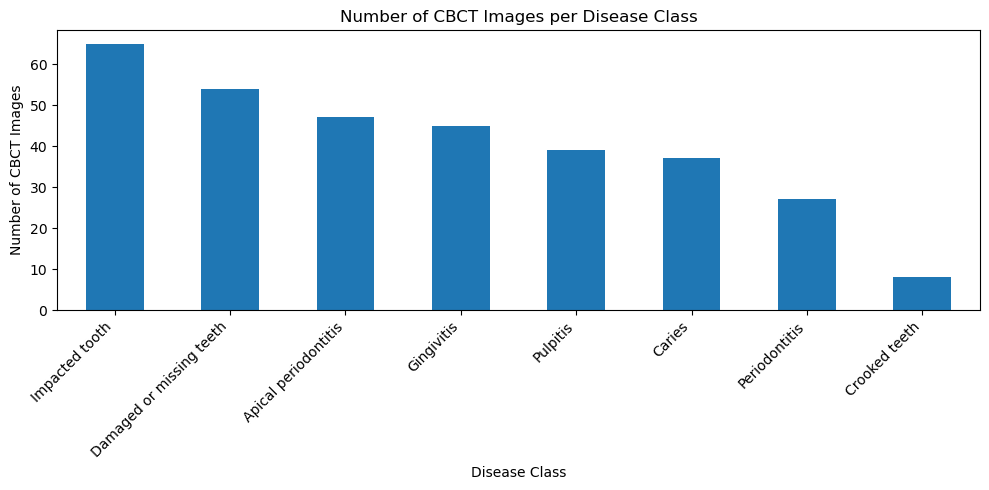

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.xlabel("Disease Class")
plt.ylabel("Number of CBCT Images")
plt.title("Number of CBCT Images per Disease Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.ndimage import rotate
from collections import Counter

In [ ]:
def random_3d_rotation(volume, max_angle=10):
    """
    volume: torch.Tensor [D,H,W] or [1,D,H,W]
    """
    original_shape = volume.shape

    # Remove channel dim if exists
    if volume.dim() == 4:
        volume = volume.squeeze(0)

    vol = volume.numpy()

    angle = random.uniform(-max_angle, max_angle)

    axes = random.choice([
        (1, 2),  # H-W
        (0, 2),  # D-W
        (0, 1)   # D-H
    ])

    vol = rotate(
        vol,
        angle=angle,
        axes=axes,
        reshape=False,
        order=1,
        mode="nearest"
    )

    vol = torch.from_numpy(vol).float()

    # Restore channel dim if needed
    if len(original_shape) == 4:
        vol = vol.unsqueeze(0)

    return vol


In [ ]:
import random

def random_flip(volume):
    if volume.dim() == 4:
        volume = volume.squeeze(0)

    for axis in [0, 1, 2]:
        if random.random() < 0.5:
            volume = torch.flip(volume, dims=[axis])

    return volume.unsqueeze(0)


In [ ]:
def add_gaussian_noise(volume, std=0.01):
    return volume + torch.randn_like(volume) * std


In [ ]:
def augment_volume(volume):
    volume = volume.float()
    volume = random_3d_rotation(volume)
    volume = random_flip(volume)
    volume = add_gaussian_noise(volume)
    return volume


In [ ]:
IMAGE_DIR = "MMDental_augmented"
SAVE_DIR = "MMDental_augmented"  # same dir, new filenames

MIN_SAMPLES = 50
augmented_rows = []

for label, count in class_counts.items():
    if count >= MIN_SAMPLES:
        continue

    print(f"Augmenting class {label}: {count} → {MIN_SAMPLES}")

    class_df = filtered_df[filtered_df["target_disease"] == label]
    needed = MIN_SAMPLES - count

    i = 0
    while i < needed:
        row = class_df.sample(1).iloc[0]
        fid = int(row["Filename"])

        img_path = os.path.join(IMAGE_DIR, f"{fid}.pt")
        volume = torch.load(img_path)

        aug_vol = augment_volume(volume)

        new_fid = f"{fid}_aug{i}"
        save_path = os.path.join(SAVE_DIR, f"{new_fid}.pt")
        torch.save(aug_vol, save_path)

        new_row = row.copy()
        new_row["Filename"] = new_fid
        augmented_rows.append(new_row)

        i += 1


Augmenting class Apical periodontitis: 47 → 50


C:\Users\T2510590\AppData\Local\Temp\ipykernel_6828\2105765847.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  volume = torch.load(img_path)


Augmenting class Gingivitis: 45 → 50
Augmenting class Pulpitis: 39 → 50
Augmenting class Caries: 37 → 50
Augmenting class Periodontitis: 27 → 50
Augmenting class Crooked teeth: 8 → 50


In [ ]:
aug_df = pd.DataFrame(augmented_rows)
final_aug_df = pd.concat([filtered_df, aug_df], ignore_index=True)

final_aug_df.to_csv("mmdental_multiclass_balanced.csv", index=False)

print("Augmentation complete")
print(final_aug_df["label"].value_counts())


Augmentation complete
label
5    65
4    54
1    50
0    50
2    50
7    50
6    50
3    50
Name: count, dtype: int64
